# Quantum Machine Learning

This notebook is the fourth in the tutorial sequence. The first notebook introduced quantum circuits and examples; the second developed their linear algebra; the third studied algorithmic cost and computational complexity. Now we connect those ideas to **quantum machine learning (QML)**: using quantum states, circuits, and measurements as part of a learning procedure.

The central question is not simply whether a quantum circuit can represent a complicated function. It is whether a complete learning workflow can learn the target efficiently, generalize from limited data, and outperform the best relevant classical method under realistic resource costs.

This notebook develops two common approaches, quantum kernels and variational quantum circuits, with small NumPy simulations. The simulations run on a classical computer and are intended to explain the mathematics, not demonstrate quantum speedup.

## Learning outcomes

By the end, you should be able to describe a QML data pipeline, explain quantum feature maps and kernels, interpret a variational quantum classifier, derive a parameter-shift gradient, and identify the major costs and open questions in claims of quantum advantage.

## 1. Where quantum computing enters a learning task

A supervised learning problem begins with examples $(x_i,y_i)$ and seeks a predictor $f(x)$ that performs well on unseen inputs. In QML, classical data may be encoded into a quantum state, processed by a circuit, and read out through measurements. A typical hybrid workflow is:

1. **Encode:** map an input vector $x$ into a state $|\phi(x)\rangle$ or a circuit $U_\phi(x)$.
2. **Process:** apply a fixed or trainable circuit, for example $U(\theta)|\phi(x)\rangle$.
3. **Measure:** estimate an observable such as $\langle Z\rangle$, producing a real-valued feature or prediction.
4. **Optimize:** update classical parameters to reduce a loss measured over training examples.
5. **Evaluate:** assess performance on held-out data, including shot and device uncertainty.

Quantum hardware supplies quantum state preparation, gates, and measurements. The optimizer, data pipeline, batching, and much of the evaluation are usually classical. A circuit can be only one component of a learning system.

### Three broad QML settings

- **Classical data, quantum model:** encode ordinary feature vectors into circuits and use a quantum kernel or trainable circuit. This is the setting used in the code examples below.
- **Quantum data, classical or quantum learner:** learn from measurements of quantum states, as in quantum-device calibration, state classification, or phases of matter. The input may not have an efficient classical description.
- **Quantum-assisted scientific computing:** combine quantum simulation or optimization with classical learning workflows, for example estimating properties of molecules.

These settings have different assumptions. A speedup claim for naturally quantum data does not automatically apply to ordinary tabular data, and a result on a small simulated data set does not establish a hardware advantage.

## 2. Encoding classical data into quantum states

A feature map is a rule $x\mapsto|\phi(x)\rangle$. With angle encoding, a feature controls a rotation such as $R_Y(x_j)$ or $R_Z(x_j)$. Repeating data-dependent gates and adding entangling gates can create richer dependencies among input coordinates. The feature map is part of the model: its scaling, periodicity, number of qubits, and circuit depth all matter.

An $n$-qubit statevector has $2^n$ amplitudes, but that does not mean an input with millions of features can be loaded for free. Circuit parameters, state preparation, repetitions, and measurements have costs. Many practical encodings use a number of qubits and gates that grows with the number of selected features, or compress the input classically first.

In the next example, we define an explicit two-qubit phase feature map. The four computational basis states receive phases depending on $x_1$, $x_2$, and their product. The product term makes the phase depend jointly on both coordinates. This is a deliberately small pedagogical map, not a universal best choice.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def phase_feature_state(point, interaction=1.0):
    x_first, x_second = point
    phases = np.array([
        0.0,
        x_first,
        x_second,
        x_first + x_second + interaction * x_first * x_second,
    ])
    return np.exp(1j * phases) / 2

example_state = phase_feature_state([0.5, 1.2])
print("state amplitudes:", example_state)
print("squared norm:", np.vdot(example_state, example_state).real)
assert np.isclose(np.vdot(example_state, example_state).real, 1.0)

state amplitudes: [ 0.5       +0.j          0.43879128+0.23971277j  0.18117888+0.46601954j
 -0.33313801+0.37285261j]
squared norm: 0.9999999999999999


## 3. Quantum kernels

A kernel compares examples by an inner product in a feature space. For quantum feature states, a common kernel is the squared fidelity

$$K(x,z)=|\langle\phi(x)|\phi(z)\rangle|^2.$$

The value is between zero and one. Similar states have a large kernel value; orthogonal states have value zero. A classical kernel method can use the matrix $K(x_i,x_j)$ to learn a decision rule without explicitly listing the coordinates of the feature space.

On a quantum device, one way to estimate this kernel is to prepare $|\phi(x)\rangle$, apply the inverse feature circuit for $z$, and measure whether the result is all zeros. In the ideal circuit, that probability is the squared overlap. Finite shots make the estimate noisy. The exact statevector calculation below is a classical simulation of the overlap.

In [2]:
def quantum_kernel(point_a, point_b, interaction=1.0):
    state_a = phase_feature_state(point_a, interaction)
    state_b = phase_feature_state(point_b, interaction)
    return float(abs(np.vdot(state_a, state_b)) ** 2)

training_points = np.array([
    [0.5, 0.5],
    [0.5, 2.5],
    [2.5, 0.5],
    [2.5, 2.5],
])
training_labels = np.array([1.0, -1.0, -1.0, 1.0])

kernel_matrix = np.array([
    [quantum_kernel(point_a, point_b) for point_b in training_points]
    for point_a in training_points
])
print("kernel matrix:\n", np.round(kernel_matrix, 3))
assert np.allclose(kernel_matrix, kernel_matrix.T)
assert np.allclose(np.diag(kernel_matrix), 1.0)

kernel matrix:
 [[1.    0.091 0.091 0.13 ]
 [0.091 1.    0.085 0.495]
 [0.091 0.085 1.    0.495]
 [0.13  0.495 0.495 1.   ]]


### Fit a tiny kernel classifier

For illustration, kernel ridge classification solves $(K+\lambda I)\alpha=y$ and predicts $\mathrm{sign}(\sum_i\alpha_iK(x_i,x))$. The regularization parameter $\lambda$ controls the fit's sensitivity. This is a small classical linear-algebra calculation after the kernel values are available. In a real quantum-kernel workflow, kernel estimates may require many circuit executions.

The four examples below form an XOR-like pattern: diagonal corners have label $+1$ and off-diagonal corners have label $-1$. The plot shows that the chosen quantum feature map can fit this tiny training set. It does not show that it is better than a classical nonlinear kernel, or that it generalizes to other data.

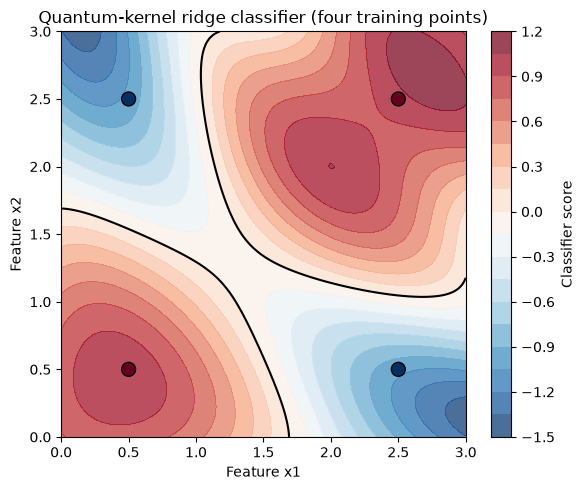

training predictions: [ 1. -1. -1.  1.]
training labels:      [ 1. -1. -1.  1.]


In [3]:
regularization = 1e-3
kernel_weights = np.linalg.solve(
    kernel_matrix + regularization * np.eye(len(training_points)),
    training_labels,
)

def predict_quantum_kernel(point):
    similarities = np.array([
        quantum_kernel(training_point, point)
        for training_point in training_points
    ])
    return float(kernel_weights @ similarities)

grid_axis = np.linspace(0.0, 3.0, 121)
grid_x, grid_y = np.meshgrid(grid_axis, grid_axis)
grid_scores = np.array([
    predict_quantum_kernel([x_value, y_value])
    for x_value, y_value in zip(grid_x.ravel(), grid_y.ravel())
]).reshape(grid_x.shape)

figure, axis = plt.subplots(figsize=(6, 5))
contours = axis.contourf(grid_x, grid_y, grid_scores, levels=20, cmap="RdBu_r", alpha=0.75)
axis.contour(grid_x, grid_y, grid_scores, levels=[0], colors="black", linewidths=1.5)
axis.scatter(training_points[:, 0], training_points[:, 1], c=training_labels, cmap="RdBu_r", edgecolors="black", s=100)
axis.set_xlabel("Feature x1")
axis.set_ylabel("Feature x2")
axis.set_title("Quantum-kernel ridge classifier (four training points)")
figure.colorbar(contours, ax=axis, label="Classifier score")
figure.tight_layout()
plt.show()

training_predictions = np.sign([predict_quantum_kernel(point) for point in training_points])
print("training predictions:", training_predictions)
print("training labels:     ", training_labels)

### Kernel costs and caveats

A full kernel matrix for $m$ training examples contains $m^2$ entries, although symmetry can reduce unique pairs. Estimating each entry with $S$ shots gives a rough circuit-sampling cost proportional to $m^2S$, before accounting for circuit depth, compilation, error mitigation, and repeated model selection. Prediction can require comparing a new example with many training examples.

A quantum kernel is useful only if the feature map is suitable for the task and the kernel values can be estimated accurately at acceptable cost. Some feature maps produce classically hard-to-compute kernels, but hardness by itself does not prove a learning advantage: the target labels must align with the kernel, learning must be statistically feasible, and classical competitors must be considered.

## 4. Variational quantum classifiers

A variational quantum circuit (VQC), also called a quantum neural network in some contexts, uses trainable gate parameters $\theta$. For input $x$, its state is often written

$$|\psi(x,\theta)\rangle=U(\theta)U_\phi(x)|0\cdots0\rangle.$$

A measured observable $O$ gives an expectation $f_\theta(x)=\langle\psi(x,\theta)|O|\psi(x,\theta)\rangle$. A classical optimizer adjusts $\theta$ to minimize a loss such as mean squared error or cross-entropy. In hardware, each expectation is estimated from repeated shots, so the loss and its gradient are noisy.

The next one-qubit example is deliberately minimal: encode a scalar input with an $R_Y(x)$ rotation, apply a trainable $R_Y(\theta)$, and predict using the $Z$ expectation. Since $R_Y(\theta)R_Y(x)=R_Y(x+\theta)$, the model output is $\cos(x+\theta)$. It is a circuit model, but this simple example is not expected to outperform a classical model.

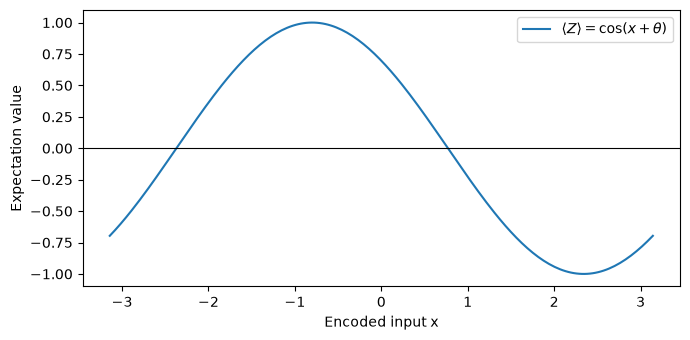

In [4]:
def one_qubit_z_expectation(angle):
    state_vector = np.array([np.cos(angle / 2), np.sin(angle / 2)])
    return float(state_vector[0] ** 2 - state_vector[1] ** 2)

inputs = np.linspace(-np.pi, np.pi, 200)
trainable_angle = 0.8
predictions = np.array([
    one_qubit_z_expectation(value + trainable_angle)
    for value in inputs
])

figure, axis = plt.subplots(figsize=(7, 3.5))
axis.plot(inputs, predictions, label=r"$\langle Z\rangle=\cos(x+\theta)$")
axis.axhline(0, color="black", linewidth=0.8)
axis.set_xlabel("Encoded input x")
axis.set_ylabel("Expectation value")
axis.set_ylim(-1.1, 1.1)
axis.legend()
figure.tight_layout()
plt.show()

### Parameter-shift gradients

Training requires derivatives of measured outputs with respect to gate parameters. For a parameter $\theta$ entering a gate generated by a Pauli operator, a common parameter-shift identity is

$$\frac{\partial f}{\partial\theta}=\frac{f(\theta+\pi/2)-f(\theta-\pi/2)}{2}.$$

This is an exact identity for the relevant gate forms, not a finite-difference approximation. On hardware, each shifted expectation is estimated with shots; estimating one gradient component therefore uses additional circuit executions. A model with many parameters and training examples can require a large number of circuit evaluations per optimizer step.

In [5]:
def parameter_shift_derivative(function, parameter):
    shift = np.pi / 2
    return (function(parameter + shift) - function(parameter - shift)) / 2

parameter = 0.7
exact_derivative = -np.sin(parameter)
shift_derivative = parameter_shift_derivative(np.cos, parameter)
print(f"analytic derivative:        {exact_derivative:.8f}")
print(f"parameter-shift derivative: {shift_derivative:.8f}")
assert np.isclose(exact_derivative, shift_derivative)

analytic derivative:        -0.64421769
parameter-shift derivative: -0.64421769


### Training can be difficult

A circuit's expressive capacity is not enough; an optimizer must find useful parameters. Deep, highly entangling circuits can exhibit **barren plateaus**, regions where typical gradients become extremely small as system size grows under certain assumptions. Shot noise, hardware noise, poor initialization, and nonconvex loss surfaces can also impede training. These problems are not universal for every ansatz, but they make circuit design and initialization central research questions.

Practical strategies include problem-informed circuit structure, shallow layers, local cost functions, careful initialization, and classical preprocessing. Each choice changes expressivity, trainability, and resource cost.

## 5. Generalization, data, and evaluation

A high training score does not imply good predictions on new examples. QML models require the same careful train/validation/test separation as classical models. Feature scaling is particularly important for angle encoding because rotations are periodic: inputs differing by $2\pi$ can encode to the same rotation. Hyperparameter tuning must not leak information from the test set.

When evaluating a proposed QML advantage, compare against strong classical baselines with comparable data access and tuning budgets. Report test metrics and uncertainty, not only training accuracy. Include the number of qubits, circuit depth, shots, optimizer evaluations, wall-clock time, and whether simulation or physical hardware was used. Small data sets and tiny circuits are useful teaching examples, not evidence of broad advantage.

## 6. When might quantum machine learning help?

A plausible advantage needs a full chain of evidence:

1. The quantum representation or operation captures useful structure in the task.
2. Preparing inputs and running the model is efficient in the relevant access model.
3. Training data, circuit depth, and shot counts remain manageable.
4. The learned model generalizes and is robust to noise.
5. The complete quantum workflow outperforms the strongest classical alternatives on a meaningful metric.

Potentially promising settings include quantum-native data and scientific problems where the desired quantity is naturally a property of a quantum system. For ordinary classical data, encoding and readout costs can erase theoretical gains. There is no general theorem that quantum models outperform classical machine learning on typical data, and the field continues to investigate when advantages exist.

## Try It

1. For the squared-overlap kernel, what are $K(x,x)$ and the range of possible values? Why?
2. The kernel matrix calculation uses every pair of training examples. How does the number of unique entries scale with $m$, the number of examples, and what other factors affect circuit cost?
3. Change `interaction` in the phase feature map to 0. What feature dependence has been removed? Does zero interaction necessarily make every classification task impossible?
4. For $f(\theta)=\cos\theta$, verify the parameter-shift formula algebraically or numerically at two different angles.
5. Name three reasons a variational circuit with many parameters may still be difficult to train.
6. Explain why fitting the four XOR-like points in the kernel example does not demonstrate a quantum advantage.

## Answers

1. $K(x,x)=|\langle\phi(x)|\phi(x)\rangle|^2=1$ for a normalized pure state. By Cauchy-Schwarz, $0\le K(x,z)\le1$.

2. There are $m(m+1)/2$ unique entries in a symmetric matrix including the diagonal, so the number scales as $O(m^2)$. Circuit depth, shots per estimate, qubit count, compilation, noise mitigation, and repetitions for tuning also affect cost.

3. Setting the interaction to zero removes the explicit product-dependent phase term $x_1x_2$. The map retains coordinate-dependent phases, so it can still support some nonlinear decision rules through the kernel; whether it can fit a task depends on the resulting feature space and data.

4. The shifted expression is $[\cos(\theta+\pi/2)-\cos(\theta-\pi/2)]/2=[-\sin\theta-\sin\theta]/2=-\sin\theta$, which equals the derivative.

5. Examples include barren plateaus with very small gradients, shot noise, hardware noise, nonconvex optimization, poor initialization, and too many circuit evaluations per gradient step.

6. The demonstration uses only four examples and an ideal classical statevector simulation. It does not evaluate held-out generalization, compare against strong classical nonlinear kernels, include quantum hardware costs, or show that the kernel is hard for classical computers to reproduce. It illustrates a feature-map mechanism only.

## Summary

Quantum machine learning combines data encoding, quantum circuits, measurement, and classical optimization. Quantum kernels use overlaps between feature states; variational models train circuit parameters against measured expectations. Both approaches face costs from state preparation, circuit execution, shots, gradients, noise, and generalization.

The main question is not whether a quantum circuit can represent a model, but whether the full learning pipeline offers a useful, reproducible advantage over strong classical methods for a well-defined task. The first three notebooks explain the quantum and algorithmic foundations; this notebook applies them to learning while keeping that evidence standard in view.